# Exploring the relationship between study time hours, sleep hours, attendance rates and final grades  

## Step 1: Import out libraries

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

## Step 2: Load the cleaned dataset

In [53]:
# open cleaned data file
df = pd.read_csv("../data/processed/student_performance_clean.csv")

df.head()

,student_id,study_time_hours,sleep_hours,attendance_rate,final_grade
0,1,4,5,91,98
1,2,5,7,68,91
2,3,3,8,100,55
3,4,5,6,94,64
4,5,5,4,78,92


## Step 3: Get the variables to create our graphs

In [54]:
# vars for plotting the relationship btw sleep hrs a& attendance rates
sleep_hours = df["sleep_hours"]
attendance_rate = df["attendance_rate"]

# vars for plotting the relationship btw study hrs & final grade
dfx = df[df["student_id"].isin([1, 2, 3, 4, 5])].sort_values("student_id")
study_hours = dfx["study_time_hours"]
final_grade = dfx["final_grade"]
student_ids = dfx["student_id"].astype(str)

## Step 4: Plot the relationship between attendance rate and sleep hours

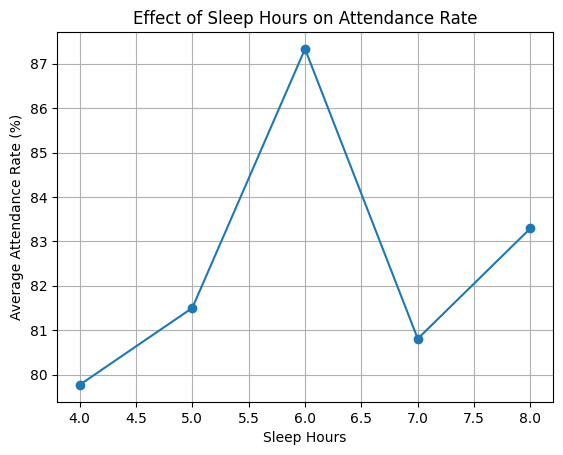

In [61]:
# plot a line graph
attendance_by_sleep = (
    df.groupby(sleep_hours)["attendance_rate"]
      .mean() # calculate average attendance
      .sort_index() # then sort from smallest to largest
)
plt.figure()
plt.plot(
    attendance_by_sleep.index,
    attendance_by_sleep.values,
    marker="o"
)
plt.xlabel("Sleep Hours")
plt.ylabel("Average Attendance Rate (%)")
plt.title("Effect of Sleep Hours on Attendance Rate")
plt.grid(True)
plt.savefig("../images/sleep_hrs_attendance_rate.png",  dpi=300, bbox_inches="tight") #save 
plt.show()

The diagram above indicates the impact that sleep has on attendance. Each point higlights the average attendance of a student sleeping for that many hrs. From the trends in the diagram, one may conclude thst the more sleep a student gets the better their attendance rate. Attendance is usually determined by physical prescence & a student is more likely to show up for class if they are well rested, althoug there are unique cases where studentes may not show up due to medical reasons, accidents and other occasions where a student nofifies the school that they will not be present which ultimately affects attendance rates. That would probably explain why one student's(student_id 2) data is does not fit the pattern.

## Step 5: Plot the relationship betwen final grades and study hours

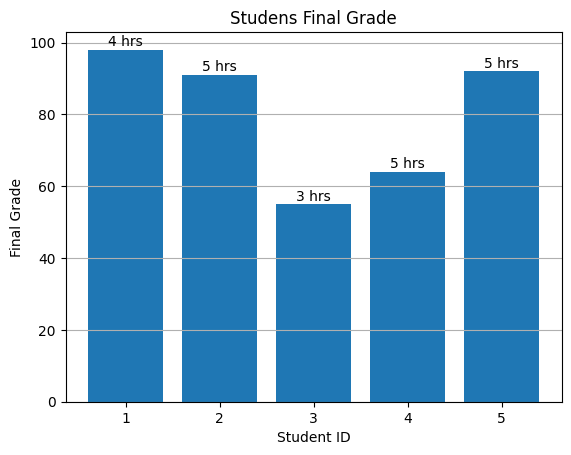

In [60]:
plt.figure()
plt.bar(student_ids, final_grade)
plt.xlabel("Student ID")
plt.ylabel("Final Grade")
plt.title("Studens Final Grade")
plt.grid(axis="y")

# notes the stufy hours on top of each bar also the zip function pairs values together in thi s case it pairs final grade & study hrs 
for i, (grade, hours) in enumerate(zip(final_grade, study_hours)):
    plt.text(i, grade + 1, f"{hours} hrs", ha="center")


plt.savefig("../images/final_grade_study_hrs.png",  dpi=300, bbox_inches="tight") #save 
plt.show()



The bar chart above expresses the relationship between personal study hours and the impact it would have on a students final grade. It is notable that the stufents who spent more time in their personal studies had higher scores than students who did not. Will explain the anomally of student 4 in conclusion.

## Conclusion

Looking at the raw data below specifically the study time hours, sleep hours & attendance rate...

In [43]:
df.head()

,student_id,study_time_hours,sleep_hours,attendance_rate,final_grade
0,1,4,5,91,98
1,2,5,7,68,91
2,3,3,8,100,55
3,4,5,6,94,64
4,5,5,4,78,92


It is very clear that students who more or less equally divided their time between the three categories which are personal study time, time spent resting & time in class perfomed better than students who majorly focused on one area & neglected another. This suggests that optimal performance would be achieved by striking a balance between getting adequate rest, consistent attendance of classes and also spending enough time on personal studies. 